In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEPS:
1. Data overview
2. Brief cleaning (filtering, changing col types, removing features, adding features)
3. EDA (visualizations)
4. Splitting data
5. Data preprocessing (imputing, encoding, transforming)
6. Modeling

GOAL:
- Segment customers based on purchase behavior with K-means clustering and compare it to Gaussian Mixture Model

In [3]:
df = pd.read_csv('customer_segmentation_data.csv')
df.drop(columns=['Segmentation Group', 'Customer ID'], inplace=True)

In [4]:
df.head()

,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language
0,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English
1,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French
2,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German
3,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French
4,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English


In [5]:
print(f'Data shape:')
print(f'{df.shape}\n----------------')

display(df.describe().T)

Data shape:
(53503, 18)
----------------


,count,mean,std,min,25%,50%,75%,max
Age,53503.0,44.140945,15.079486,18.0,32.0,43.0,57.0,70.0
Income Level,53503.0,82768.324318,36651.075670,20001.0,51568.5,80719.0,115973.5,149999.0
Coverage Amount,53503.0,492580.789638,268405.505571,50001.0,249613.5,477261.0,739124.0,1000000.0
Premium Amount,53503.0,3023.702447,1285.834295,500.0,1817.0,3194.0,4311.5,5000.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 53503 non-null  int64 
 1   Gender                              53503 non-null  object
 2   Marital Status                      53503 non-null  object
 3   Education Level                     53503 non-null  object
 4   Geographic Information              53503 non-null  object
 5   Occupation                          53503 non-null  object
 6   Income Level                        53503 non-null  int64 
 7   Behavioral Data                     53503 non-null  object
 8   Purchase History                    53503 non-null  object
 9   Interactions with Customer Service  53503 non-null  object
 10  Insurance Products Owned            53503 non-null  object
 11  Coverage Amount                     53503 non-null  in

In [7]:
missing_vals = df.isna().sum()
missing_vals

Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
dtype: int64

In [8]:
features = df.columns

for i, col in enumerate(features):
    name = col.replace(' ','_')
    print(f'Unique values in column {name.upper()}:\n{df[col].unique()}')
    print(f'Total unique values: {df[col].nunique()}')
    print('-'*50)
    print('\n')



Unique values in column AGE:
[23 26 29 20 25 41 55 35 43 32 69 47 31 65 64 53 48 62 58 56 68 70 63 45
 51 52 27 33 38 40 54 24 36 42 30 34 67 44 57 37 59 61 21 46 19 39 60 49
 22 28 50 66 18]
Total unique values: 53
--------------------------------------------------


Unique values in column GENDER:
['Female' 'Male']
Total unique values: 2
--------------------------------------------------


Unique values in column MARITAL_STATUS:
['Married' 'Widowed' 'Single' 'Divorced' 'Separated']
Total unique values: 5
--------------------------------------------------


Unique values in column EDUCATION_LEVEL:
['Associate Degree' 'Doctorate' "Bachelor's Degree" "Master's Degree"
 'High School Diploma']
Total unique values: 5
--------------------------------------------------


Unique values in column GEOGRAPHIC_INFORMATION:
['Mizoram' 'Goa' 'Rajasthan' 'Sikkim' 'West Bengal' 'Uttar Pradesh'
 'Himachal Pradesh' 'Manipur' 'Gujarat' 'Andaman and Nicobar Islands'
 'Tripura' 'Nagaland' 'Karnataka' 'Odi

In [9]:
df = df.drop_duplicates()

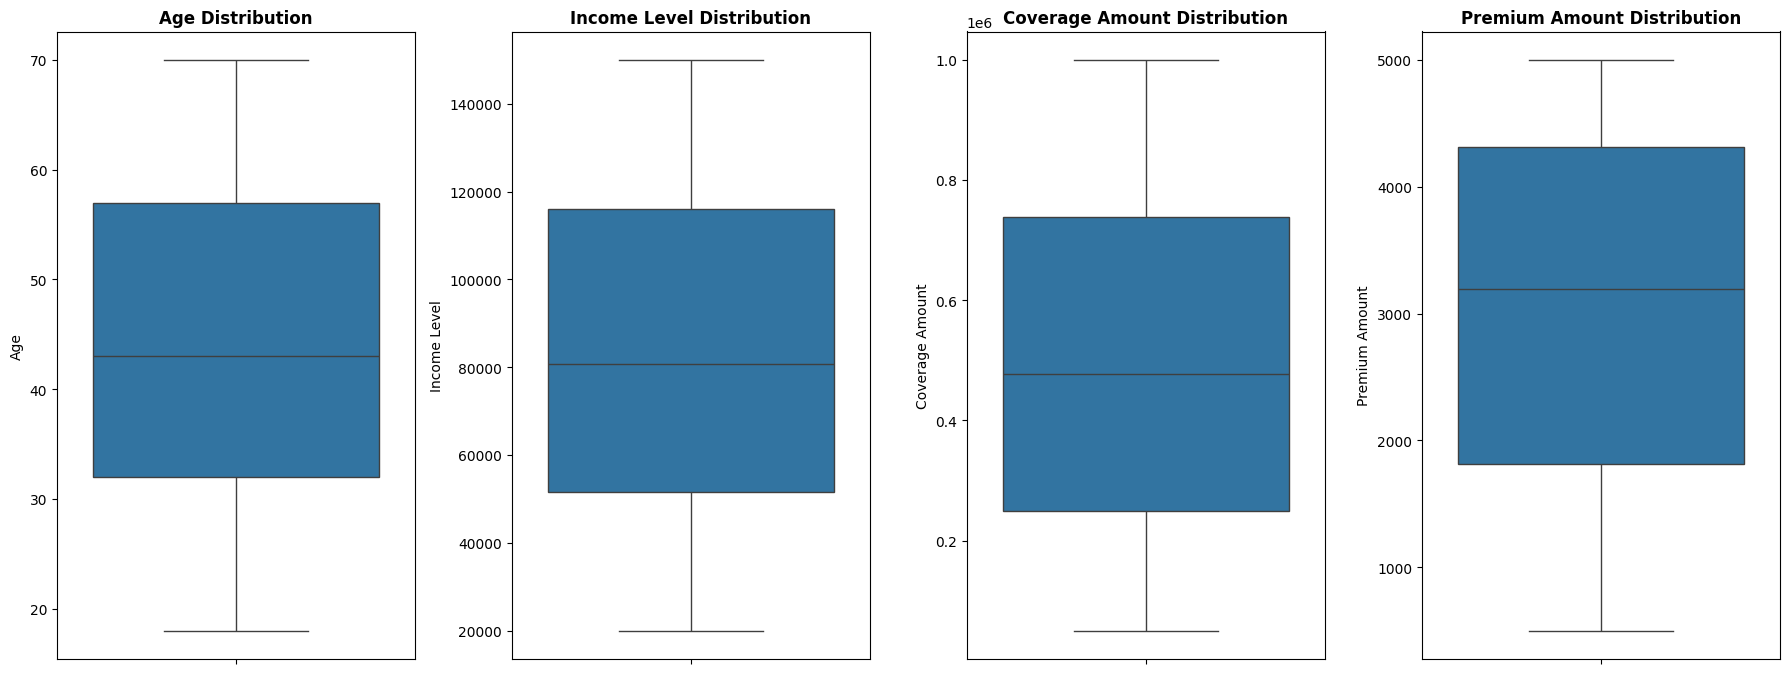

In [ ]:
num_features = df.select_dtypes('int64')

fig, ax = plt.subplots(1,4,figsize=(18,7))

for i ,f in enumerate(num_features):
    sns.boxplot(data=df[f], ax=ax[i])
    ax[i].set_title(f'{f} Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

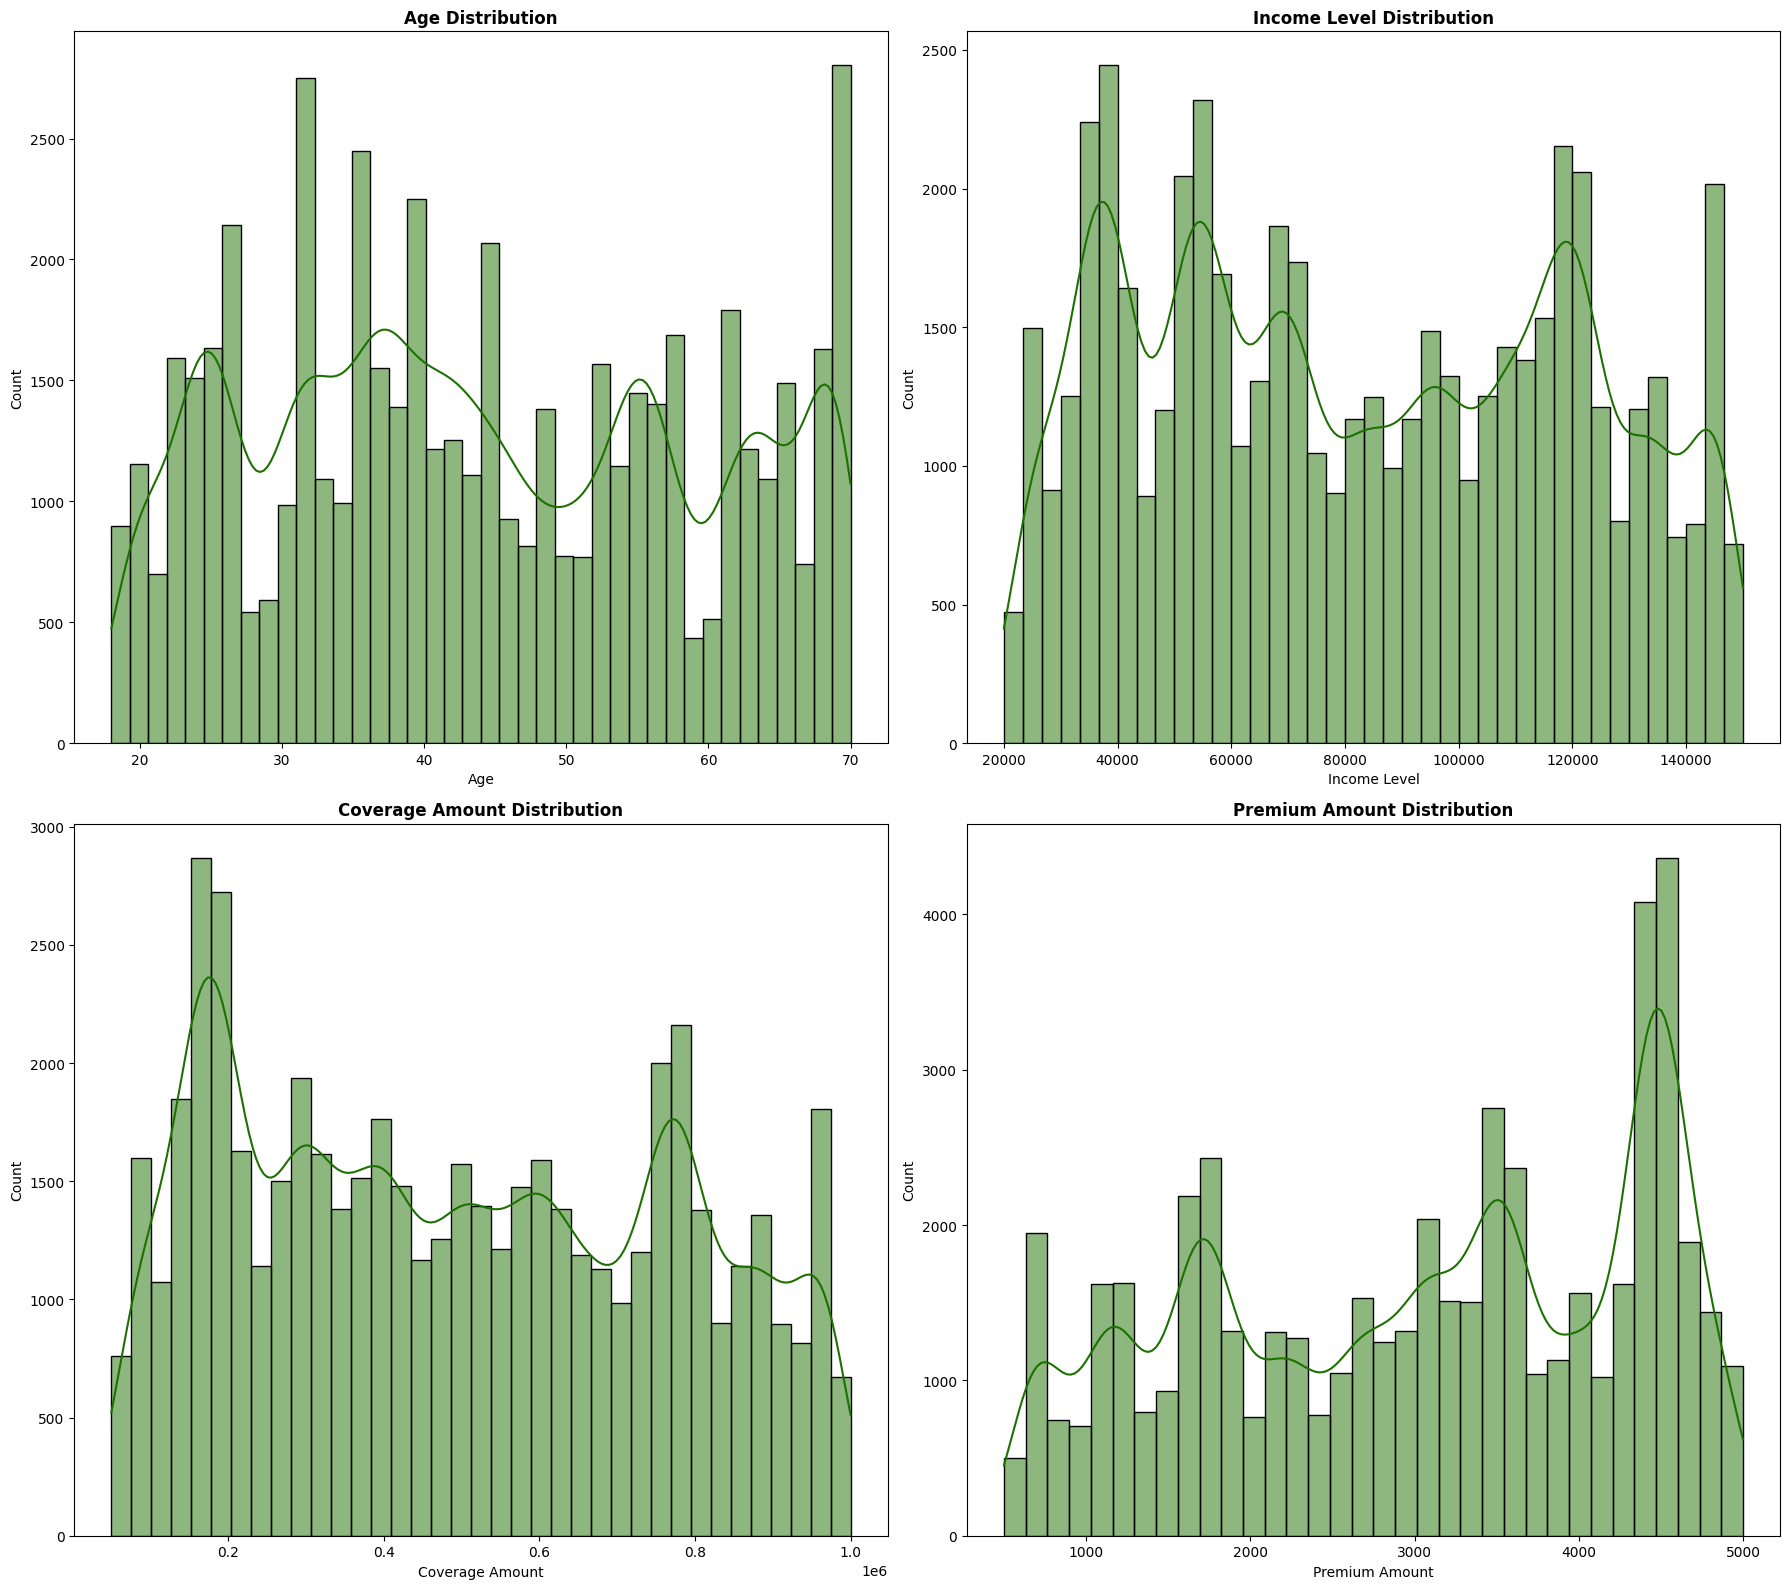

In [11]:
fig, ax = plt.subplots(2,2,figsize=(18,16))

for i ,f in enumerate(num_features):
    sns.histplot(data=df[f], kde=True, ax=ax.flat[i], color="#1C7100")
    ax.flat[i].set_title(f'{f} Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

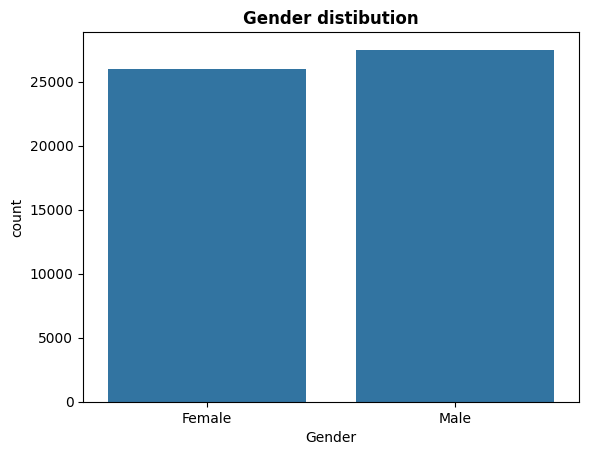

In [12]:
sns.countplot(data=df, x='Gender')
plt.title('Gender distibution', fontweight='bold')
plt.show()

C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\263689697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\263689697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\263689697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\263689697.py:6: Futur

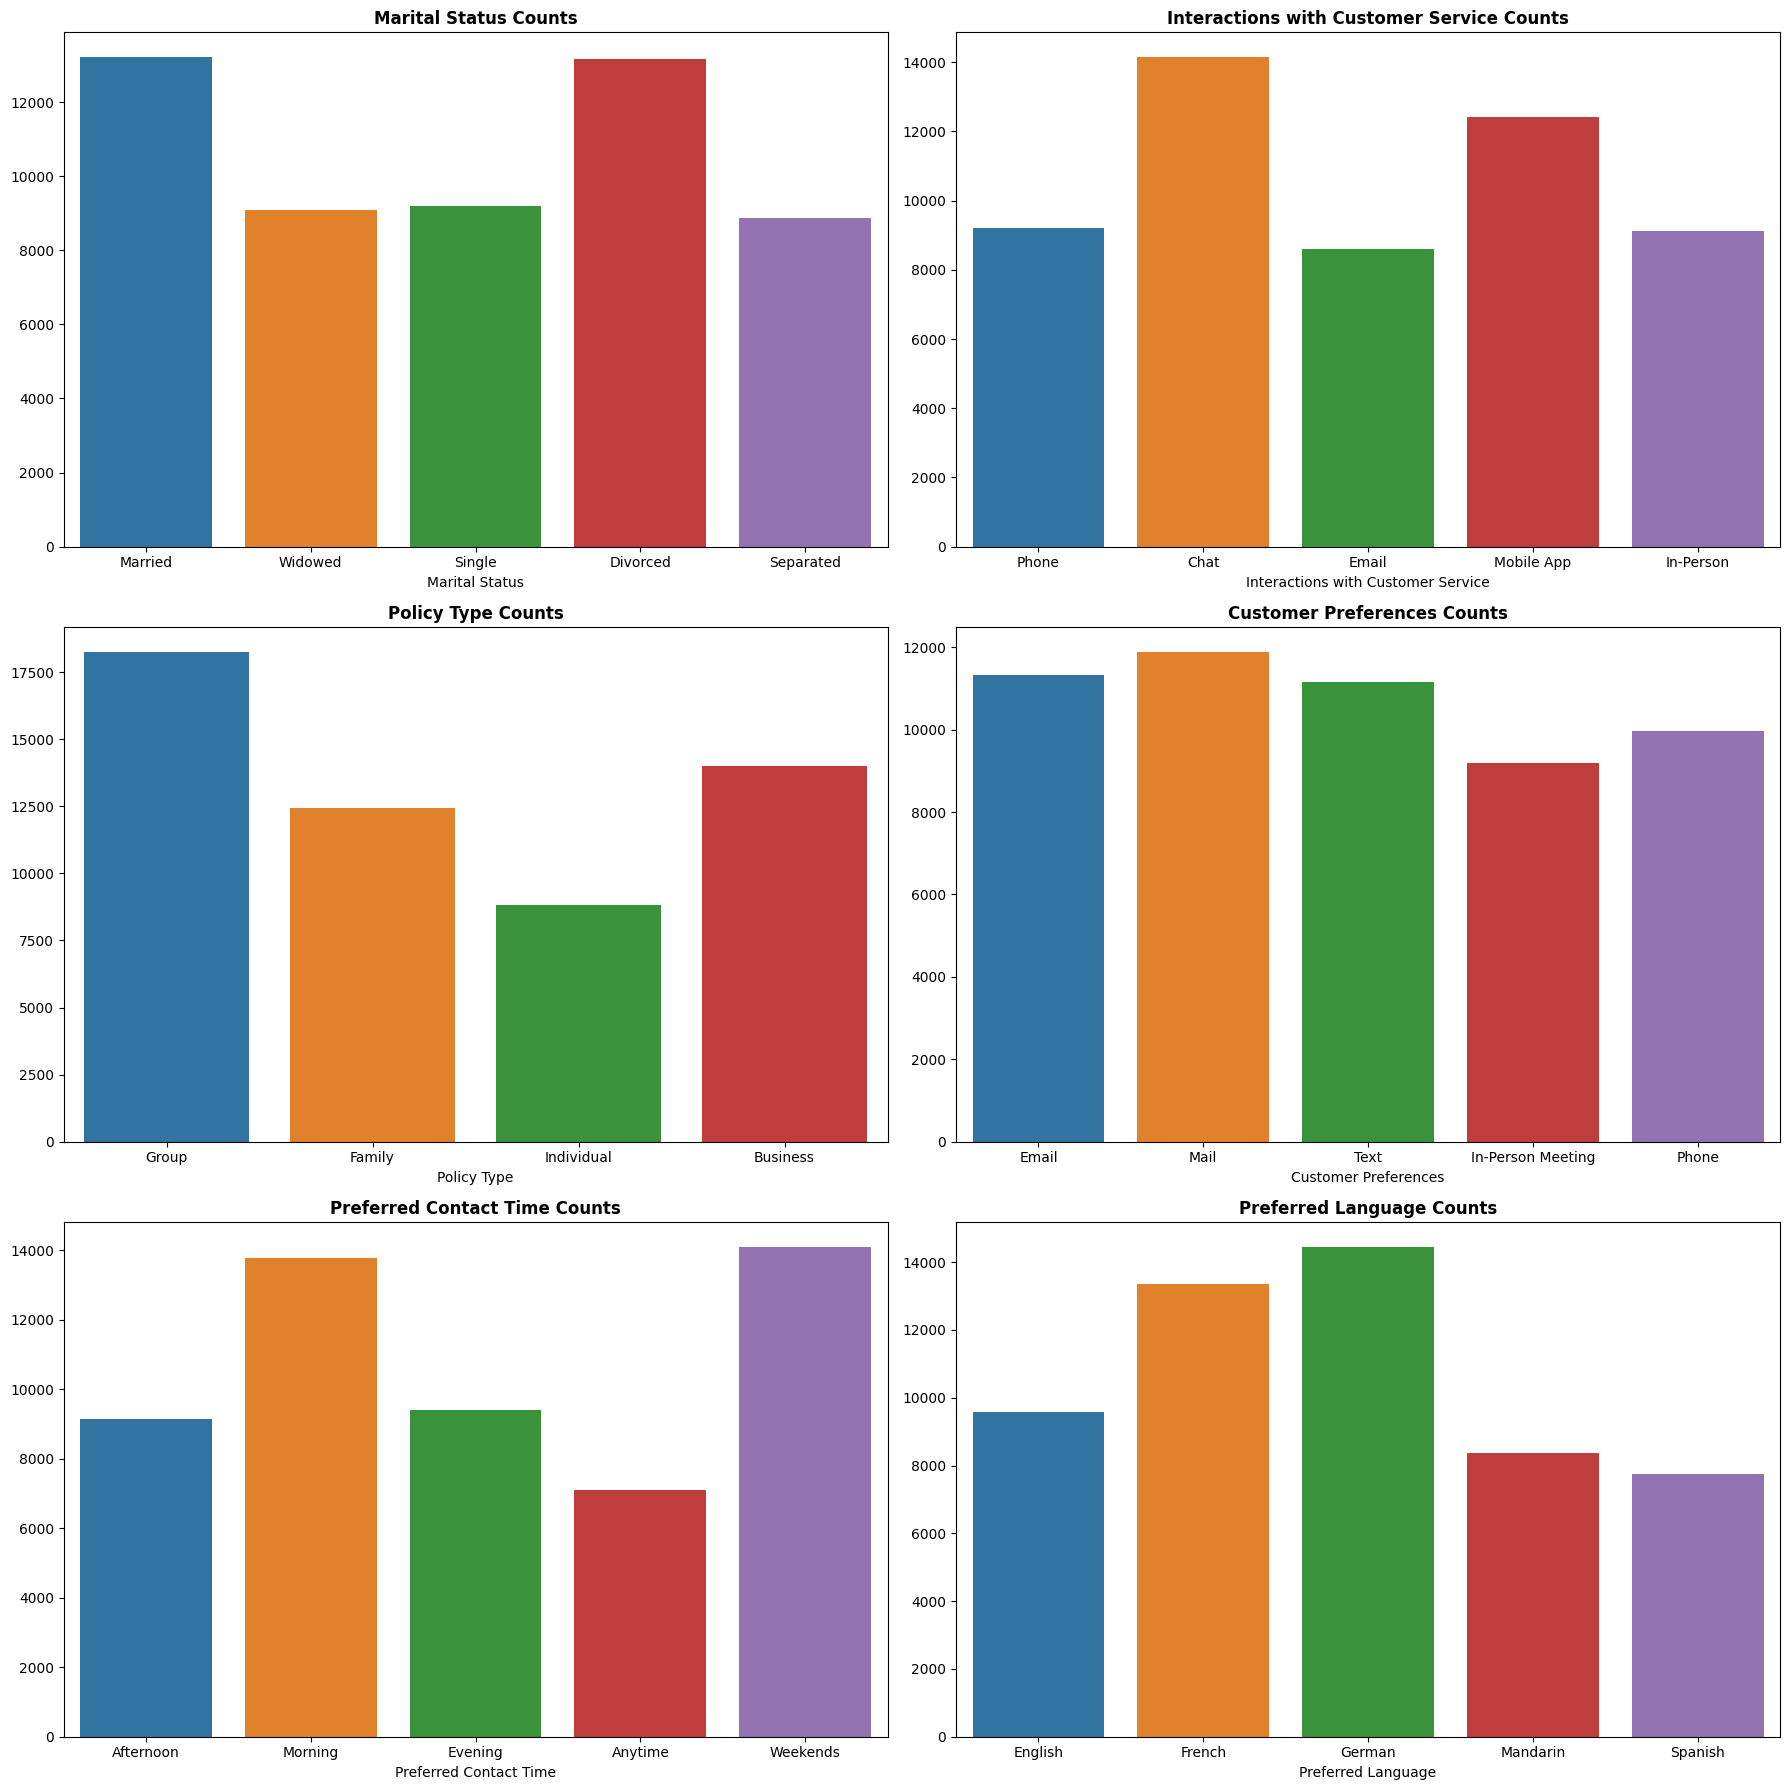

In [13]:
feat_to_plot = ['Marital Status', 'Interactions with Customer Service', 'Policy Type', 'Customer Preferences', 'Preferred Contact Time', 'Preferred Language']

fig, ax = plt.subplots(3,2,figsize=(18,18))

for i, f in enumerate(feat_to_plot):
    sns.countplot(data=df, x=f, ax=ax.flat[i], palette='tab10')
    ax.flat[i].set_title(f'{f} Counts', fontweight='bold')
    ax.flat[i].set_ylabel('')

plt.tight_layout()

C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\4241168652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Premium Amount', palette='tab10', ax=ax[0])
C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\4241168652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Coverage Amount', palette='tab10', ax=ax[1])


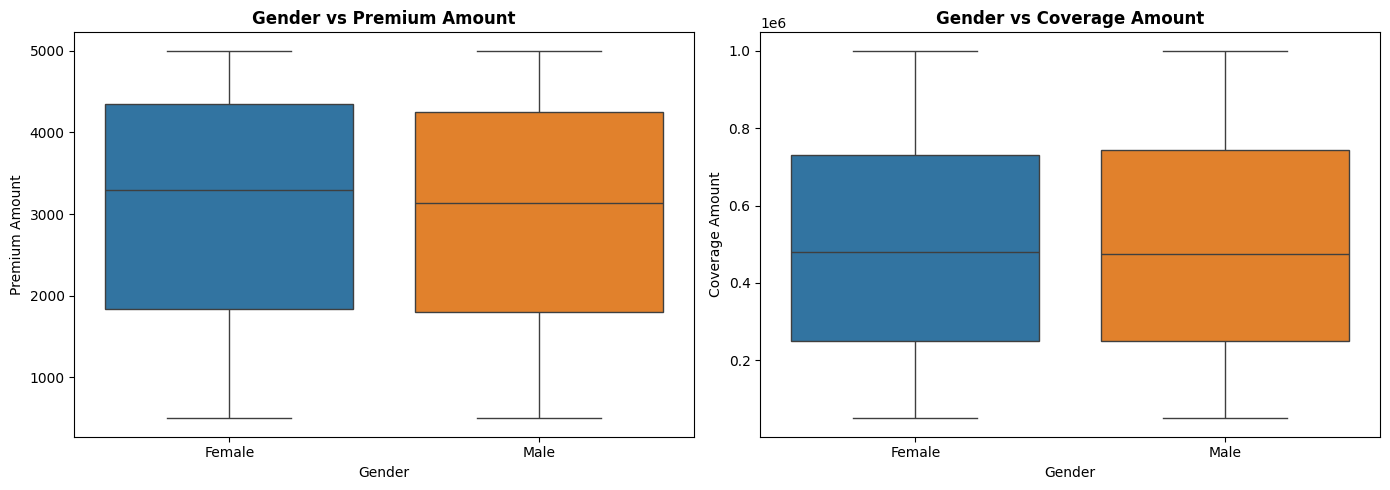

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Gender', y='Premium Amount', palette='tab10', ax=ax[0])
sns.boxplot(data=df, x='Gender', y='Coverage Amount', palette='tab10', ax=ax[1])
ax[0].set_title('Gender vs Premium Amount', fontweight='bold')
ax[1].set_title('Gender vs Coverage Amount', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\mHomi\AppData\Local\Temp\ipykernel_7144\2752509147.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='month', y='purchases', ax=ax[1], palette='tab10')


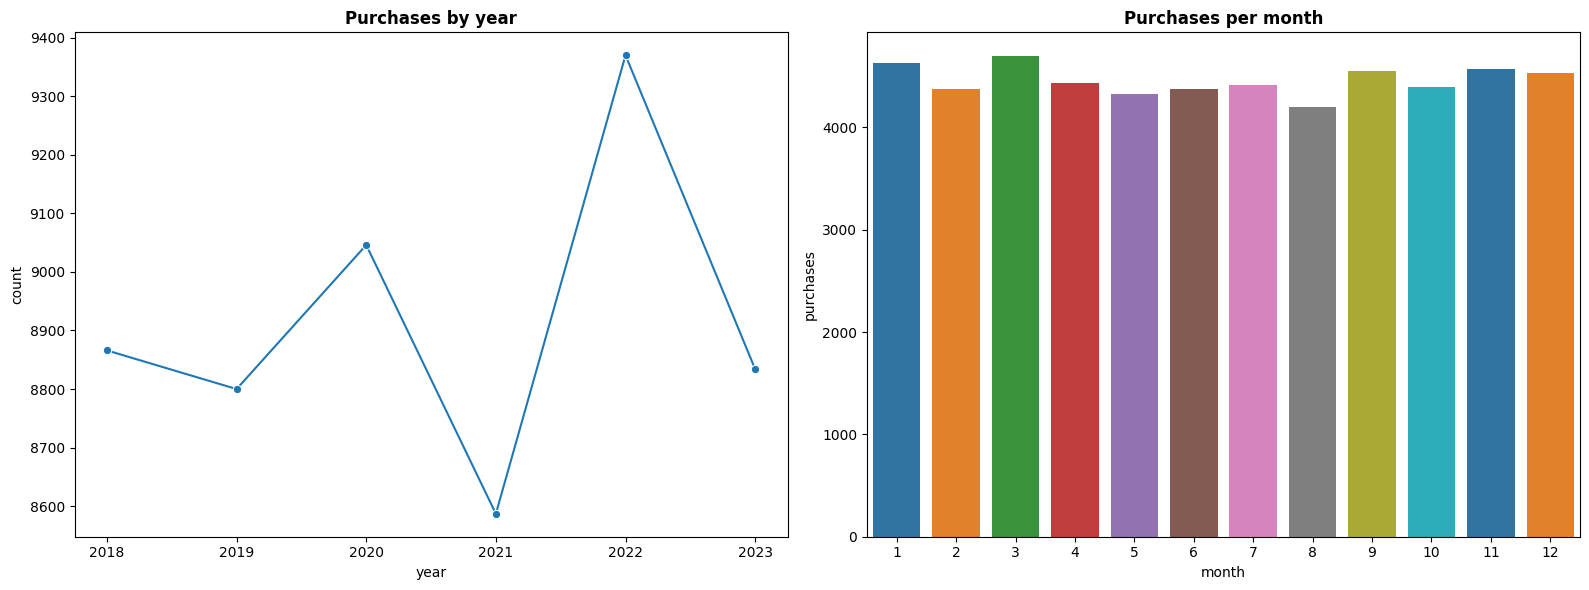

In [17]:
mask_slash = df['Purchase History'].str.contains('/')
mask_dash  = df['Purchase History'].str.contains('-')

df.loc[mask_slash, 'Purchase History'] = pd.to_datetime(
    df.loc[mask_slash, 'Purchase History'], format='%m/%d/%Y')

df.loc[mask_dash, 'Purchase History'] = pd.to_datetime(
    df.loc[mask_dash, 'Purchase History'], format='%m-%d-%Y')

df['Purchase History'] = pd.to_datetime(df['Purchase History'])

yearly = df.groupby(df['Purchase History'].dt.year).size().reset_index()
yearly.columns = ['year', 'count']
yearly['year'] = yearly['year'].astype('str')

monthly = df.groupby(df['Purchase History'].dt.month).size().reset_index()
monthly.columns = ['month', 'purchases']

fig, ax = plt.subplots(1,2,figsize=(16,6))

sns.lineplot(data=yearly, x='year', y='count', marker='o', ax=ax[0])
ax[0].set_title('Purchases by year', fontweight='bold')

sns.barplot(data=monthly, x='month', y='purchases', ax=ax[1], palette='tab10')
ax[1].set_title('Purchases per month', fontweight='bold')

plt.tight_layout()
plt.show()




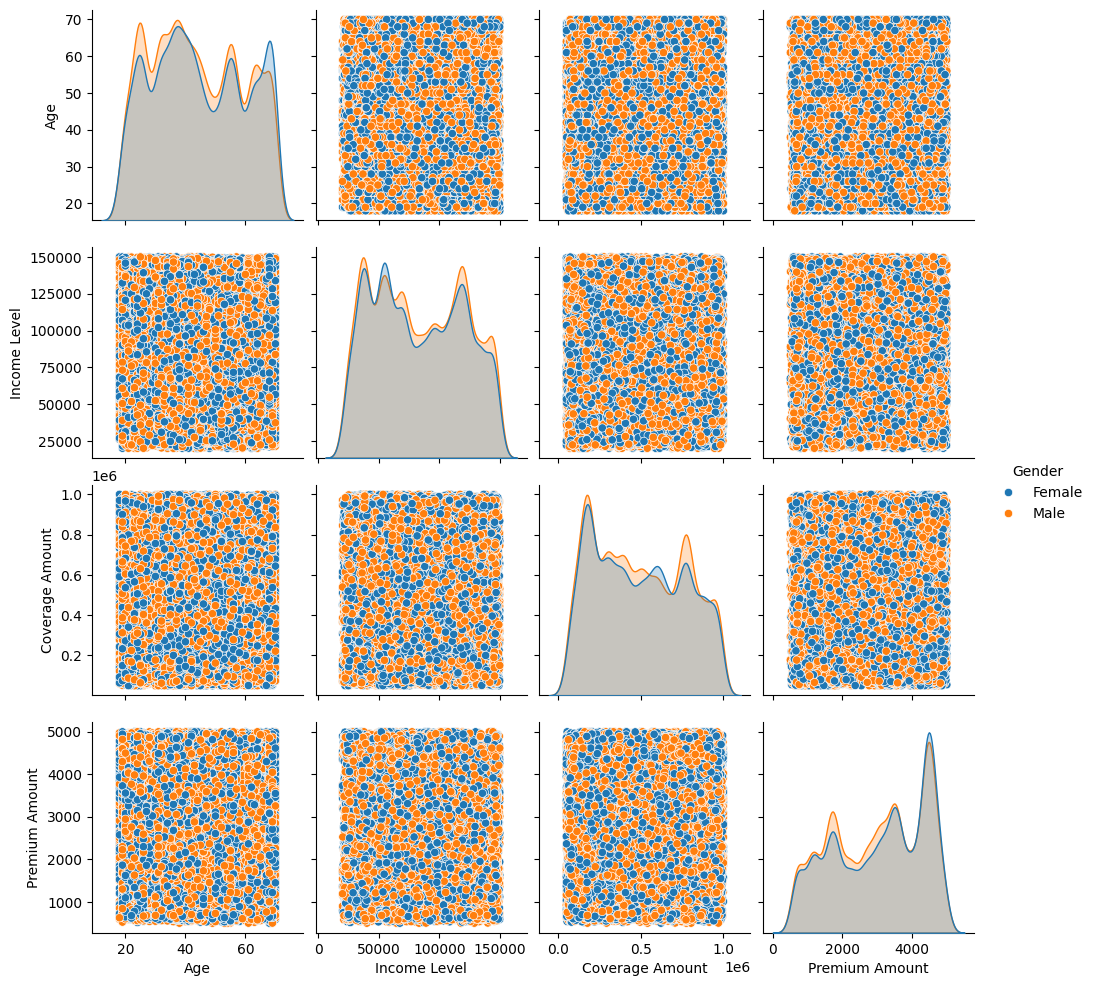

In [18]:
sns.pairplot(df, hue='Gender')
plt.show()

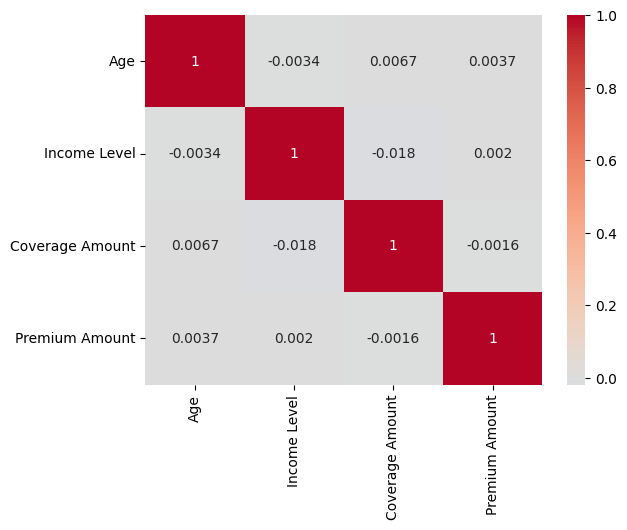

In [19]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.show()